# Evaluation on trained models

In [1]:
# mainly loading the environment used for training. Unify everything. (run context)
from dirs import *
from train import *

c:\Users\qiyuanxu\Documents\GitHub\fiber-image-reconstruction-comparison


c:\Users\qiyuanxu\AppData\Local\miniconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Prepare
Manually handle the practical complexity, by loading different trained models and prepare relavant evaluation dataset 

In [ ]:
""" 2025 CLEAR CAE trained on real beam chromox line scan + SGM """

# ========================================
# Load model
# ========================================
import torch
from models.CAE import Autoencoder2D

model_name = "chromox_cropped_cae_random_scan"    # chromox_cae_random_scan; chromox_cropped_cae_line_scan_sgm; chromox_cropped_cae_random_scan
model_path = dirs["models"][model_name] # should point to model.pth
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder2D.load_model(
    filepath=model_path,  # should point to model.pth
    device=device,
    eval_mode=True, # inference mode
)
print(show_model_info(model))

# ========================================
# load dataset for inference
# ========================================
from xflow.utils.visualization import plot_image

experiment_name = "CLEAR25"
dataset_sources = ["processed_chromox_cropped"]  # ["processed_dmd", "processed_chromox", "processed_yag", "processed_chromox_laser", "processed_yag_laser", "processed_chromox_cropped"]'

config_manager = ConfigManager(
    load_config(
        f"{experiment_name}.yaml",
        machine=detect_machine(),
        resolve=True,
    )
)
config = config_manager.get()
dataset_dirs = [resolve_dataset_dir(config, src) for src in dataset_sources]
db_rel = config["dataset_structure"]["db"].lstrip("/\\")
db_paths = [d / db_rel for d in dataset_dirs]

eval_provider = SqlProvider(
    sources={"connection": db_paths[0], "sql": config["sql"]["processed_chromox_cropped_random_scan_eval"]}, output_config={'list': "image_path"}
)#.subsample(n_samples=300, seed=config["seed"])

# pad abs path to db saved relative dirs.
for t in config["data"]["transforms"]["torch"]:
    if t.get("name") == "add_parent_dir":
        t.setdefault("params", {})["parent_dir"] = str(dataset_dirs[0])
        break
transforms = build_transforms_from_config(config["data"]["transforms"]["torch"])

# normally leave the pipelines decoupled and untouched so the output interface remains consistent.
eval_dataset = PyTorchPipeline(
    eval_provider,
    transforms
).to_memory_dataset(config["data"]["dataset_ops"])  # testset data do not need thresholding since it is to remove stacking noise?

print("Samples: ", len(eval_provider))
print("Batch: ", len(eval_dataset))
plot_image(next(iter(eval_dataset))[0])
plot_image(next(iter(eval_dataset))[1])

# Inference
get and save intermediate result, fixed downstream (mainly plotting) contract

In [ ]:
"""
MMF speckle reconstruction inference with per-sample image triplets saved to disk.

Ported from the old flat script. The domain-specific logic (triplet figure
saving) lives in TripletSaverHook; the runner handles iteration, device,
eval mode, and batch unpacking.
"""
from xflow.evaluation.runner import (
    run_evaluation,
    TqdmHook,
)
from xflow.extensions.physics.runner import TripletSaverHook, BeamParamCSVHook

# ----------------------------
# Entry point
# ----------------------------
# Expected to be defined in the surrounding notebook / script:
#   model, eval_dataset, device, dirs, model_name

save_dir = dirs["save"]["model_inference"][model_name]
saver = TripletSaverHook(save_dir=save_dir)
beam_csv = BeamParamCSVHook(
    csv_path=os.path.join(save_dir, "beam_parameters.csv"),
    methods=("moments", "gaussian"),
    append=True,
    flush_every=256,
)
ctx = run_evaluation(
    model=model,
    dataset=eval_dataset,
    device=device,
    hooks=[TqdmHook(), saver, beam_csv],
)

print(f"batches: {ctx.seen_batches}, samples: {ctx.seen_samples}")
print(f"beam parameters saved to: {os.path.join(save_dir, 'beam_parameters.csv')}")

# Visualization
Completely decoupled from above, read only intermediate results with fixed contract, only focus on high quality publication level image, each block is one plot

In [ ]:
"""Resuable components, Run once for all evaluations"""

import pandas as pd
from dirs import *

def load_beam_param_df(csv_path):
    df = pd.read_csv(csv_path, skipinitialspace=True)
    df.columns = (
        df.columns.astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
    )
    return df


# =========================================================
# Generic NaN/inf row cleaner
# Drops any row containing NaN or ±inf in any column.
# Returns a new df; original is untouched.
# =========================================================

def drop_invalid_rows(df):
    mask = df.replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
    return df.loc[mask].reset_index(drop=True)


_DIMS_PARAMS = [
    ("h", "centroid"),
    ("v", "centroid"),
    ("h", "width"),
    ("v", "width"),
]

## Classic three statistical plots on testset
(Scatter plot, residual plot and error distribution histogram)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from xflow.extensions.style.aps import APS_COLORS, set_aps_double_column

# =========================================================
# Data utilities
# =========================================================

def _col_names(fit_method, param_type, dim):
    fit_method = str(fit_method).strip().lower()
    param_type = str(param_type).strip().lower()
    gt_col = f"label_{fit_method}_{dim}_{param_type}"
    pred_col = f"reconstructed_{fit_method}_{dim}_{param_type}"
    return gt_col, pred_col


def prepare_plot_df(df, param_type, fit_method, dims=("h", "v")):
    out = df.copy().replace([np.inf, -np.inf], np.nan)

    active_dims = []
    needed_cols = []
    for dim in dims:
        gt_col, pred_col = _col_names(fit_method, param_type, dim)
        if gt_col in out.columns and pred_col in out.columns:
            active_dims.append(dim)
            needed_cols.extend([gt_col, pred_col])

    if not active_dims:
        raise ValueError(
            f"No usable columns for fit_method={fit_method}, param_type={param_type}."
        )

    for c in needed_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")

    # Keep rows that have at least one valid pair among active dimensions
    valid_mask = np.zeros(len(out), dtype=bool)
    for dim in active_dims:
        gt_col, pred_col = _col_names(fit_method, param_type, dim)
        pair_ok = out[gt_col].notna() & out[pred_col].notna()
        valid_mask |= pair_ok

    out = out.loc[valid_mask].reset_index(drop=True)
    return out, active_dims


def _pair(df, fit_method, param_type, dim):
    gt_col, pred_col = _col_names(fit_method, param_type, dim)
    if gt_col not in df.columns or pred_col not in df.columns:
        return np.array([], dtype=float), np.array([], dtype=float)

    gt = pd.to_numeric(df[gt_col], errors="coerce").to_numpy(dtype=float)
    pred = pd.to_numeric(df[pred_col], errors="coerce").to_numpy(dtype=float)
    m = np.isfinite(gt) & np.isfinite(pred)
    return gt[m], pred[m]


def _new_ax():
    set_aps_double_column(figsize=FIGSIZE, scale=1.0, legend_background=True)
    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    ax.set_box_aspect(1)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        length=TICK_MAJOR_LEN,
        width=TICK_WIDTH,
    )
    ax.tick_params(
        axis="both",
        which="minor",
        length=TICK_MINOR_LEN,
        width=TICK_WIDTH,
    )
    return fig, ax


def _legend(ax):
    ax.legend(
        fontsize=LEGEND_FONT_SIZE,
        frameon=True,
        facecolor="white",
        edgecolor="black",
        framealpha=0.95,
    )


# =========================================================
# Plot 1: Prediction vs Ground Truth
# =========================================================
def plot_pred_vs_label(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
):
    fig, ax = _new_ax()

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        ax.scatter(
            gt,
            pred,
            s=SCATTER_POINT_SIZE,
            alpha=0.72,
            marker="o",
            color=DIM_STYLE[dim]["color"],
            edgecolors="none",
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

    ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], "--", lw=REF_LINE_WIDTH, color=REF_COLOR)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])
    ax.set_aspect("equal", adjustable="box")

    # ax.set_title(f"{fit_method.capitalize()} | {param_type.capitalize()}", fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel("Ground truth", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Prediction", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


# =========================================================
# Plot 2: Residual vs Ground Truth (normalized residual)
# residual = pred - gt
# =========================================================
def plot_residual_vs_label(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    xlim=(0.0, 1.0),
    ylim=(-1.0, 1.0),
):
    fig, ax = _new_ax()

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        residual = pred - gt
        residual = np.clip(residual, ylim[0], ylim[1])

        ax.scatter(
            gt,
            residual,
            s=SCATTER_POINT_SIZE,
            alpha=0.72,
            marker="o",
            color=DIM_STYLE[dim]["color"],
            edgecolors="none",
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

    ax.axhline(0.0, ls="--", lw=REF_LINE_WIDTH, color=REF_COLOR)

    ax.set_xlim(xlim[0], xlim[1])
    ax.set_ylim(ylim[0], ylim[1])

    # ax.set_title(f"{fit_method.capitalize()} | {param_type.capitalize()}", fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel("Ground truth", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Residual (pred - gt)", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


# =========================================================
# Plot 3: Residual percentage histogram
# residual_pct = (pred - gt) * 100
# x-range fixed by input and clipped
# =========================================================
def plot_residual_hist_pct(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    x_range_pct=(-100.0, 100.0),
    bins=40,
    y_max=None,
):
    fig, ax = _new_ax()
    x_min, x_max = float(x_range_pct[0]), float(x_range_pct[1])
    hist_bins = np.linspace(x_min, x_max, int(bins) + 1)

    for dim in dims:
        gt, pred = _pair(df, fit_method, param_type, dim)
        if gt.size == 0:
            continue

        residual_pct = (pred - gt) * 100.0
        residual_pct = residual_pct[np.isfinite(residual_pct)]
        if residual_pct.size == 0:
            continue

        # Force x-range and cut off rest
        residual_pct = np.clip(residual_pct, x_min, x_max)

        counts, edges, _ = ax.hist(
            residual_pct,
            bins=hist_bins,
            alpha=0.38,
            color=DIM_STYLE[dim]["color"],
            label=f"{DIM_STYLE[dim]['name']} {param_type}",
        )

        # Gaussian fit line (no legend entry requested)
        if residual_pct.size > 1:
            mu = float(np.mean(residual_pct))
            sigma = float(np.std(residual_pct, ddof=1))
            if sigma > 0:
                xfit = np.linspace(edges[0], edges[-1], 300)
                bw = edges[1] - edges[0]
                yfit = (
                    residual_pct.size
                    * bw
                    * (1.0 / (sigma * np.sqrt(2.0 * np.pi)))
                    * np.exp(-0.5 * ((xfit - mu) / sigma) ** 2)
                )
                ax.plot(xfit, yfit, lw=2.0, color=DIM_STYLE[dim]["color"], alpha=0.95)

    ax.axvline(0.0, ls="--", lw=REF_LINE_WIDTH, color=REF_COLOR)
    ax.set_xlim(x_min, x_max)

    if y_max is not None:
        ax.set_ylim(0.0, float(y_max))

    # ax.set_title(f"{fit_method.capitalize()} | {param_type.capitalize()}", fontsize=TITLE_FONT_SIZE)
    ax.set_xlabel("Residual (%)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Count", fontsize=AXIS_LABEL_SIZE)
    _legend(ax)
    return fig, ax


def make_three_plots(
    df,
    param_type="centroid",
    fit_method="gaussian",
    dims=("h", "v"),
    pred_gt_xlim=(0.0, 1.0),
    pred_gt_ylim=(0.0, 1.0),
    residual_xlim=(0.0, 1.0),
    residual_ylim=(-1.0, 1.0),
    hist_x_range_pct=(-100.0, 100.0),
    hist_bins=40,
    hist_y_max=None,
):
    clean_df, active_dims = prepare_plot_df(
        df=df,
        param_type=param_type,
        fit_method=fit_method,
        dims=dims,
    )

    f1, _ = plot_pred_vs_label(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        xlim=pred_gt_xlim,
        ylim=pred_gt_ylim,
    )

    f2, _ = plot_residual_vs_label(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        xlim=residual_xlim,
        ylim=residual_ylim,
    )

    f3, _ = plot_residual_hist_pct(
        clean_df,
        param_type=param_type,
        fit_method=fit_method,
        dims=active_dims,
        x_range_pct=hist_x_range_pct,
        bins=hist_bins,
        y_max=hist_y_max,
    )

    return f1, f2, f3




# =========================================================
# Global controls (edit here)
# =========================================================
MODEL_NAME = "chromox_cropped_cae_random_scan"  # chromox_cae_random_scan; chromox_cropped_cae_line_scan_sgm; chromox_cropped_cae_random_scan
FIT_METHOD = "gaussian"          # "gaussian" or "moments"
PARAM_TYPES = ("centroid", "width")

# Dimension selection
DIMS_TO_USE = ("h", "v")         # any subset of ("h", "v")

# Figure style
FIGSIZE = (3.8, 3.8)             # square, same for all plots
SCATTER_POINT_SIZE = 5
REF_LINE_WIDTH = 2.4

# Font / tick sizes
TICK_LABEL_SIZE = 11
AXIS_LABEL_SIZE = 12
TITLE_FONT_SIZE = 13
LEGEND_FONT_SIZE = 10
TICK_MAJOR_LEN = 5
TICK_MINOR_LEN = 3
TICK_WIDTH = 1.0

# Plot 1 (pred vs gt): fixed normalized range
PRED_GT_XLIM = (0.0, 1.0)
PRED_GT_YLIM = (0.0, 1.0)

# Plot 2 (residual vs gt): normalized residual, fixed y range
RESIDUAL_SCATTER_XLIM = (0.0, 1.0)
RESIDUAL_SCATTER_YLIM = (-1.0, 1.0)   # requested fixed range

# Plot 3 (residual histogram in percent)
HIST_X_RANGE_PCT = (-50.0, 50.0)    # can change to (-50, 50), etc.
HIST_BINS = 50                         # user control
HIST_Y_MAX = 350                       # set None for auto

# Save control
SAVE_PREFIX = "_"


# =========================================================
# Visual mapping
# =========================================================
DIM_STYLE = {
    "h": {"name": "Horizontal", "color": APS_COLORS[4]},
    "v": {"name": "Vertical", "color": APS_COLORS[5]},
}
REF_COLOR = APS_COLORS[7]

# =========================================================
# Final application code
# =========================================================
save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")
df = load_beam_param_df(csv_path)

for param_type in PARAM_TYPES:
    fig1, fig2, fig3 = make_three_plots(
        df=df,
        param_type=param_type,
        fit_method=FIT_METHOD,
        dims=DIMS_TO_USE,
        pred_gt_xlim=PRED_GT_XLIM,
        pred_gt_ylim=PRED_GT_YLIM,
        residual_xlim=RESIDUAL_SCATTER_XLIM,
        residual_ylim=RESIDUAL_SCATTER_YLIM,
        hist_x_range_pct=HIST_X_RANGE_PCT,   # e.g. (-50, 50)
        hist_bins=HIST_BINS,
        hist_y_max=HIST_Y_MAX,
    )

    fig1.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{FIT_METHOD}_{param_type}_scatter_pred_vs_gt.png"))
    fig2.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{FIT_METHOD}_{param_type}_scatter_residual_vs_gt.png"))
    fig3.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}{FIT_METHOD}_{param_type}_hist_residual_percent.png"))

## Error distribution correlation with both parameters
Hexegon plot of error shade on each parameter distribution

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable
from xflow.extensions.style.aps import set_aps_double_column

# =========================================================
# Font / tick size controls
# =========================================================
TICK_LABEL_SIZE   = 11   # x/y tick numbers on the main axes
AXIS_LABEL_SIZE   = 12   # x/y axis labels
CBAR_TICK_SIZE    = 10   # colorbar tick numbers
CBAR_LABEL_SIZE   = 11   # colorbar label ("Mean |error|")
CBAR_NUM_TICKS    = 5    # target number of colorbar ticks (MaxNLocator picks nice values near this)
TICK_MAJOR_LEN    = 5
TICK_MINOR_LEN    = 3
TICK_WIDTH        = 1.0


# =========================================================
# Error column module
# error_gaussian_{dim}_{param} = label - prediction
# =========================================================
def add_gaussian_error_columns(df):
    out = df.copy()
    for dim, param in _DIMS_PARAMS:
        label_col = f"label_gaussian_{dim}_{param}"
        pred_col  = f"reconstructed_gaussian_{dim}_{param}"
        err_col   = f"error_gaussian_{dim}_{param}"
        out[err_col] = (
            pd.to_numeric(out[label_col], errors="coerce")
            - pd.to_numeric(out[pred_col], errors="coerce")
        )
    return out


# =========================================================
# Hexbin: label_h vs label_v, color = mean |error|
# =========================================================
def plot_hex_error_2d(
    df,
    param_type="centroid",      # "centroid" or "width"
    gridsize=25,                # hexagon size control
    xlim=(0.0, 1.0),
    ylim=(0.0, 1.0),
    range_mode="full",          # "full": use xlim/ylim as given (default).
                                # "tight": auto-scale to data min/max, shared square range.
    cmap="viridis",
    vmax=None,
    figsize=(3.8, 3.8),
):
    x   = df[f"label_gaussian_h_{param_type}"].to_numpy()
    y   = df[f"label_gaussian_v_{param_type}"].to_numpy()
    e_h = df[f"error_gaussian_h_{param_type}"].to_numpy()
    e_v = df[f"error_gaussian_v_{param_type}"].to_numpy()
    mae = 0.5 * (np.abs(e_h) + np.abs(e_v))

    # Resolve plot range.
    # "full"  → keep user-provided xlim/ylim (normalized [0,1] by default).
    # "tight" → compute a shared [lo, hi] over x and y so the box stays square
    #           under set_aspect("equal") + set_box_aspect(1), with small padding.
    if range_mode == "tight":
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.02 * (hi - lo) if hi > lo else 0.01
        xlim = (lo - pad, hi + pad)
        ylim = xlim

    set_aps_double_column(figsize=figsize, scale=1.0, legend_background=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_box_aspect(1)

    hb = ax.hexbin(
        x, y, C=mae,
        reduce_C_function=np.mean,
        gridsize=gridsize,
        cmap=cmap,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        vmin=0.0, vmax=vmax,
        mincnt=1,
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"Horizontal {param_type} (label)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(f"Vertical {param_type} (label)",   fontsize=AXIS_LABEL_SIZE)
    # ax.set_title(f"Gaussian | {param_type.capitalize()}")

    ax.tick_params(
        axis="both", which="major",
        labelsize=TICK_LABEL_SIZE,
        length=TICK_MAJOR_LEN, width=TICK_WIDTH,
    )
    ax.tick_params(
        axis="both", which="minor",
        length=TICK_MINOR_LEN, width=TICK_WIDTH,
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cb = fig.colorbar(hb, cax=cax)
    cb.set_label("Mean |error|", fontsize=CBAR_LABEL_SIZE)

    # Colorbar tick count + tick label size
    cb.locator = MaxNLocator(nbins=CBAR_NUM_TICKS)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=CBAR_TICK_SIZE, length=TICK_MAJOR_LEN, width=TICK_WIDTH)

    return fig, ax


gridsize = 20
range_mode = "full"   # "full" or "tight"
MODEL_NAME = "chromox_cropped_cae_random_scan" 
SAVE_PREFIX = "_"

save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")

df = load_beam_param_df(csv_path)
df = add_gaussian_error_columns(df)
df = drop_invalid_rows(df)   # blanket clean: drop any row with NaN/inf anywhere

fig_c, _ = plot_hex_error_2d(df, param_type="centroid", gridsize=gridsize, range_mode=range_mode)
fig_w, _ = plot_hex_error_2d(df, param_type="width",    gridsize=gridsize, range_mode=range_mode)

fig_c.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_centroid_hex_error.png"), bbox_inches="tight")
fig_w.savefig(os.path.join(save_dir, f"{SAVE_PREFIX}gaussian_width_hex_error.png"), bbox_inches="tight")

# Statistical overview of entire testset

In [ ]:
import json
import numpy as np
import os

# Metric registry — add entries here to extend.
# Each metric takes (y_true, y_pred) as 1D numpy arrays and returns a float.
_METRICS = {
    "mse":       lambda y, yh: float(np.mean((y - yh) ** 2)),
    "rmse":      lambda y, yh: float(np.sqrt(np.mean((y - yh) ** 2))),
    "mae":       lambda y, yh: float(np.mean(np.abs(y - yh))),
    "medae":     lambda y, yh: float(np.median(np.abs(y - yh))),
    "max_error": lambda y, yh: float(np.max(np.abs(y - yh))),
    "r2":        lambda y, yh: float(1.0 - np.sum((y - yh) ** 2) / np.sum((y - np.mean(y)) ** 2)),
}

def compute_fit_metrics(
    df,
    fit_methods=("gaussian", "moments"),   # iterable of fit methods to compute
    metrics=("rmse", "mse"),
    save_path=None,
):
    """
    For each fit_method × (dim, param) × metric, compute the metric between
    label_* and reconstructed_*. Returns a flat dict keyed as
        {fit_method}_{dim}_{param}_{metric}
    e.g. gaussian_h_centroid_rmse, moments_v_width_r2.
    Dumps JSON if save_path is provided. Assumes df is already cleaned.
    """
    unknown = [m for m in metrics if m not in _METRICS]
    if unknown:
        raise ValueError(f"Unknown metrics: {unknown}. Available: {sorted(_METRICS)}")

    results = {}
    for fit_method in fit_methods:
        for dim, param in _DIMS_PARAMS:
            y  = df[f"label_{fit_method}_{dim}_{param}"].to_numpy(dtype=float)
            yh = df[f"reconstructed_{fit_method}_{dim}_{param}"].to_numpy(dtype=float)
            for m in metrics:
                results[f"{fit_method}_{dim}_{param}_{m}"] = _METRICS[m](y, yh)

    if save_path is not None:
        with open(save_path, "w") as f:
            json.dump(results, f, indent=2)

    return results


MODEL_NAME = "chromox_cropped_cae_random_scan"
save_dir = dirs["save"]["model_inference"][MODEL_NAME]
csv_path = os.path.join(save_dir, "beam_parameters.csv")
df = load_beam_param_df(csv_path)
df = drop_invalid_rows(df)

metrics_dict = compute_fit_metrics(
    df,
    fit_methods=("gaussian", "moments"),
    metrics=("rmse", "mae", "r2", "mse"),
    save_path=os.path.join(save_dir, f"{SAVE_PREFIX}fit_metrics.json"),
)
metrics_dict

# Cross model summary
this part read final statistics across different run and give a final conclusion

In [4]:
from pathlib import Path
import json
import pandas as pd
from xflow.utils.io import scan_files

def collect_fit_metrics(
    root_dir,
    save_csv=True,
    csv_name="cross_model_fit_metrics_summary.csv",
):
    root_dir = Path(root_dir)

    all_json = scan_files(root_dir, extensions=".json", return_type="path", recursive=True)
    metric_files = [Path(p) for p in all_json if Path(p).name == "_fit_metrics.json"]

    rows = []
    for fp in metric_files:
        with open(fp, "r", encoding="utf-8") as f:
            row = json.load(f)  # assumes same keys across all files
        row["model"] = fp.parent.parent.name  # .../<model>/inference/_fit_metrics.json
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).set_index("model").sort_index()

    if save_csv:
        out_csv = root_dir / csv_name
        df.to_csv(out_csv, index=True)
        print(f"Saved CSV: {out_csv}")

    return df

# usage
root_dir = dirs["models"]["root"]
df = collect_fit_metrics(root_dir)
df

Saved CSV: C:\Users\qiyuanxu\Desktop\Models\cross_model_fit_metrics_summary.csv


,gaussian_h_centroid_rmse,gaussian_h_centroid_mae,gaussian_h_centroid_r2,gaussian_h_centroid_mse,gaussian_v_centroid_rmse,gaussian_v_centroid_mae,gaussian_v_centroid_r2,gaussian_v_centroid_mse,gaussian_h_width_rmse,gaussian_h_width_mae,...,moments_v_centroid_r2,moments_v_centroid_mse,moments_h_width_rmse,moments_h_width_mae,moments_h_width_r2,moments_h_width_mse,moments_v_width_rmse,moments_v_width_mae,moments_v_width_r2,moments_v_width_mse
model,,,,,,,,,,,,,,,,,,,,,
chromox_cae_random_scan,0.131530,0.054306,0.595587,0.017300,0.076664,0.034035,0.837921,0.005877,0.141254,0.046419,...,0.692754,0.007200,0.116395,0.107860,-4.315020,0.013548,0.108071,0.102505,-5.343588,0.011679
chromox_cropped_cae_line_scan_sgm,0.141918,0.070214,0.645622,0.020141,0.130800,0.065281,0.730679,0.017109,0.085946,0.041586,...,0.695350,0.015046,0.138006,0.129322,-6.008720,0.019046,0.129599,0.120418,-4.431116,0.016796
chromox_cropped_cae_random_scan,0.068524,0.027020,0.913636,0.004695,0.087288,0.031078,0.872996,0.007619,0.041796,0.014927,...,0.900902,0.004653,0.087497,0.078230,-1.766744,0.007656,0.081481,0.071217,-1.175723,0.006639


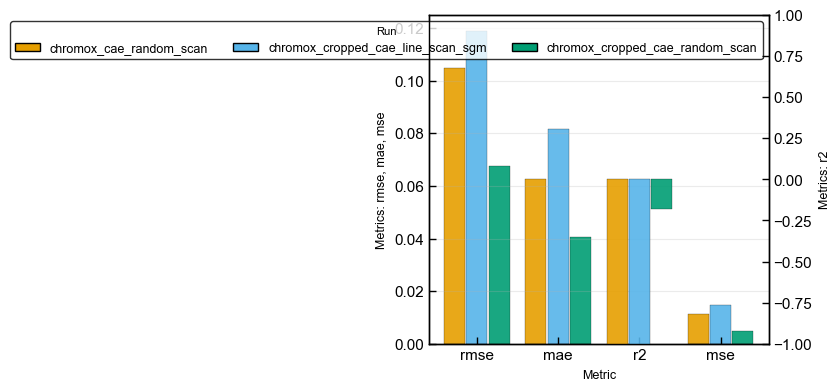

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from xflow.extensions.style.aps import APS_COLORS, set_aps_double_column

# 1) Collapse your wide metrics df into one value per metric per experiment row
#    Example input columns: gaussian_h_centroid_rmse, moments_v_width_rmse, ...
#    Output columns: rmse, mse, mae, r2, ...
def summarize_fit_metrics(df, agg="mean"):
    known_metrics = ("max_error", "medae", "rmse", "mse", "mae", "r2")

    def metric_name(col):
        c = str(col)
        for m in sorted(known_metrics, key=len, reverse=True):
            if c.endswith("_" + m):
                return m
        return c.rsplit("_", 1)[-1]  # fallback

    metric_to_cols = {}
    metric_order = []
    for c in df.columns:
        m = metric_name(c)
        metric_to_cols.setdefault(m, []).append(c)
        if m not in metric_order:
            metric_order.append(m)

    out = pd.DataFrame(index=df.index)
    for m in metric_order:
        vals = df[metric_to_cols[m]].apply(pd.to_numeric, errors="coerce")
        out[m] = vals.mean(axis=1) if agg == "mean" else vals.median(axis=1)

    return out


# 2) Grouped bar plot with automatic 1-axis / 2-axis by metric convention
#    - same range group -> same y-axis
#    - second range group -> right y-axis
#    - third range group -> raise exception
def plot_fit_metrics_grouped_bars(df, agg="mean", figsize=(7.2, 3.8)):
    summary = summarize_fit_metrics(df, agg=agg)
    if summary.empty:
        raise ValueError("No data to plot.")

    metrics = list(summary.columns)
    runs = [str(i) for i in summary.index.tolist()]

    def range_group(metric):
        m = metric.lower()
        if m == "r2":
            return "r2"          # fixed [-1, 1]
        if m in {"accuracy", "acc", "precision", "recall", "f1", "auc", "auroc"}:
            return "unit01"      # fixed [0, 1]
        return "positive"        # default [0, auto]

    group_of = {m: range_group(m) for m in metrics}
    groups_in_order = []
    for m in metrics:
        g = group_of[m]
        if g not in groups_in_order:
            groups_in_order.append(g)

    if len(groups_in_order) > 2:
        raise ValueError(
            f"Only support up to two y-axis ranges, got {groups_in_order}."
        )

    left_group = groups_in_order[0]
    right_group = groups_in_order[1] if len(groups_in_order) == 2 else None

    set_aps_double_column(figsize=figsize, scale=1.0, legend_background=True)
    fig, ax_left = plt.subplots(figsize=figsize, constrained_layout=True)
    ax_right = ax_left.twinx() if right_group is not None else None

    n_runs = len(runs)
    x = np.arange(len(metrics), dtype=float)
    total_width = 0.82
    bar_w = total_width / max(n_runs, 1)
    offsets = (np.arange(n_runs) - (n_runs - 1) / 2.0) * bar_w
    colors = [APS_COLORS[i % len(APS_COLORS)] for i in range(n_runs)]

    for i, run in enumerate(runs):
        y = summary.loc[run, metrics].to_numpy(dtype=float)
        xs = x + offsets[i]

        left_mask = np.array([group_of[m] == left_group for m in metrics], dtype=bool)
        ax_left.bar(
            xs[left_mask],
            y[left_mask],
            width=bar_w * 0.95,
            color=colors[i],
            edgecolor="black",
            linewidth=0.2,
            alpha=0.9,
        )

        if ax_right is not None:
            right_mask = ~left_mask
            ax_right.bar(
                xs[right_mask],
                y[right_mask],
                width=bar_w * 0.95,
                color=colors[i],
                edgecolor="black",
                linewidth=0.2,
                alpha=0.9,
            )

    # x-axis
    ax_left.set_xticks(x)
    ax_left.set_xticklabels(metrics)
    ax_left.set_xlabel("Metric")

    # y-axis ranges by convention
    def apply_range(ax, group):
        if group == "r2":
            ax.set_ylim(-1.0, 1.0)
        elif group == "unit01":
            ax.set_ylim(0.0, 1.0)
        else:
            ax.set_ylim(bottom=0.0)

    apply_range(ax_left, left_group)
    if ax_right is not None:
        apply_range(ax_right, right_group)

    # clear labels: show which metrics use each axis
    left_metrics = [m for m in metrics if group_of[m] == left_group]
    ax_left.set_ylabel("Metrics: " + ", ".join(left_metrics))

    if ax_right is not None:
        right_metrics = [m for m in metrics if group_of[m] == right_group]
        ax_right.set_ylabel("Metrics: " + ", ".join(right_metrics))

    # APS-like ticks/grid
    for ax in [ax_left] + ([ax_right] if ax_right is not None else []):
        ax.tick_params(axis="both", which="major", labelsize=11, length=5, width=1.0)
        ax.tick_params(axis="both", which="minor", length=3, width=1.0)
    ax_left.grid(axis="y", alpha=0.25)

    # legend = experiment/run colors
    handles = [Patch(facecolor=colors[i], edgecolor="black", label=runs[i]) for i in range(n_runs)]
    ax_left.legend(handles=handles, title="Run", fontsize=9, frameon=True, ncol=min(n_runs, 3))

    return fig, (ax_left, ax_right), summary


# usage:
fig, axes, summary_df = plot_fit_metrics_grouped_bars(df, agg="mean")
plt.show()